In [1]:
import os, copy
import glob

import numpy as np
import pandas as pd
import xarray as xr

import geopandas as gpd
import datetime as dt

import matplotlib as mpl
import matplotlib.pyplot as plt
#import colorcet as cc

import panel as pn

#hv.extension('bokeh')
pn.extension()
import grstbx
from grstbx import visual

opj = os.path.join


### set file path

In [2]:
file = '/data/satellite/prisma/touria/L2A/bassas/PRS_L2A_hgrs_20240316074117_20240316074121_0001.nc'
file = '/data/satellite/prisma/L2A/PRS_L2A_20230226103653_20230226103658_0001.nc'#50124154311_20250124154315_0001.nc' #L2A/mayotte/PRS_L2A_hgrs_20240604071915_20240604071919_0001.nc'
#file = '/data/satellite/prisma/touria/L2A/glorieuse/PRS_L2A_hgrs_20240529071520_20240529071524_0001.nc'


### load image

In [3]:
l2a_raster =xr.open_dataset(file,decode_coords='all')
#date = dt.datetime.strptime(l2a_raster.acquisition_date,'%Y-%m-%dT%H:%M:%S.%f')
#l2a_raster.acquisition_date
l2a_raster.load()

<xarray.Dataset> Size: 2GB
Dimensions:           (x: 1200, y: 1200, wl: 173, yc: 60, xc: 60)
Coordinates:
  * x                 (x) float32 5kB -3.773 -3.773 -3.772 ... -3.379 -3.379
  * y                 (y) float32 5kB -26.85 -26.85 -26.85 ... -26.52 -26.52
    time              datetime64[ns] 8B 2023-02-26T10:36:53.748000
  * wl                (wl) float32 692B 407.0 415.8 ... 2.457e+03 2.463e+03
    spatial_ref       int64 8B 0
  * xc                (xc) float32 240B -3.77 -3.763 -3.757 ... -3.389 -3.382
  * yc                (yc) float32 240B -26.84 -26.84 -26.83 ... -26.53 -26.52
Data variables: (12/18)
    tcwv_full         (y, x) float64 12MB nan nan nan nan ... nan nan nan nan
    aot_ref_full      (y, x) float64 12MB nan nan nan nan ... nan nan nan nan
    vza               float32 4B 20.34
    azi               float32 4B 39.82
    sza               float32 4B 31.29
    Rrs               (wl, y, x) float64 2GB nan nan nan nan ... nan nan nan nan
    ...                ...
    aot_ref_smoothed  (yc, xc) float64 29kB nan nan nan nan ... nan nan nan nan
    water_pix_prop    (yc, xc) float64 29kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    brdfg_full        (y, x) float64 12MB nan nan nan nan ... nan nan nan nan
    pressure          float64 8B 1.022e+03
    to3c              float64 8B 0.005436
    tno2c             float64 8B 3.85e-06
Attributes: (12/39)
    regrid_method:                   bilinear
    description:                     PRISMA L2A-hGRS cube data
    L1C_product_name:                PRS_L1_STD_OFFL_20230226103653_202302261...
    acquisition_date:                <xarray.DataArray 'time' ()> Size: 8B\na...
    sza:                             31.673914
    saa:                             60.576042
    ...                              ...
    to3c:                            0.005436410661786795
    tno2c:                           3.850236225844128e-06
    tch4c:                           0.010348167270421982
    psl:                             1013
    coef_abs_scat:                   0.9
    altitude:                        0

### Plot spectral  Rrs

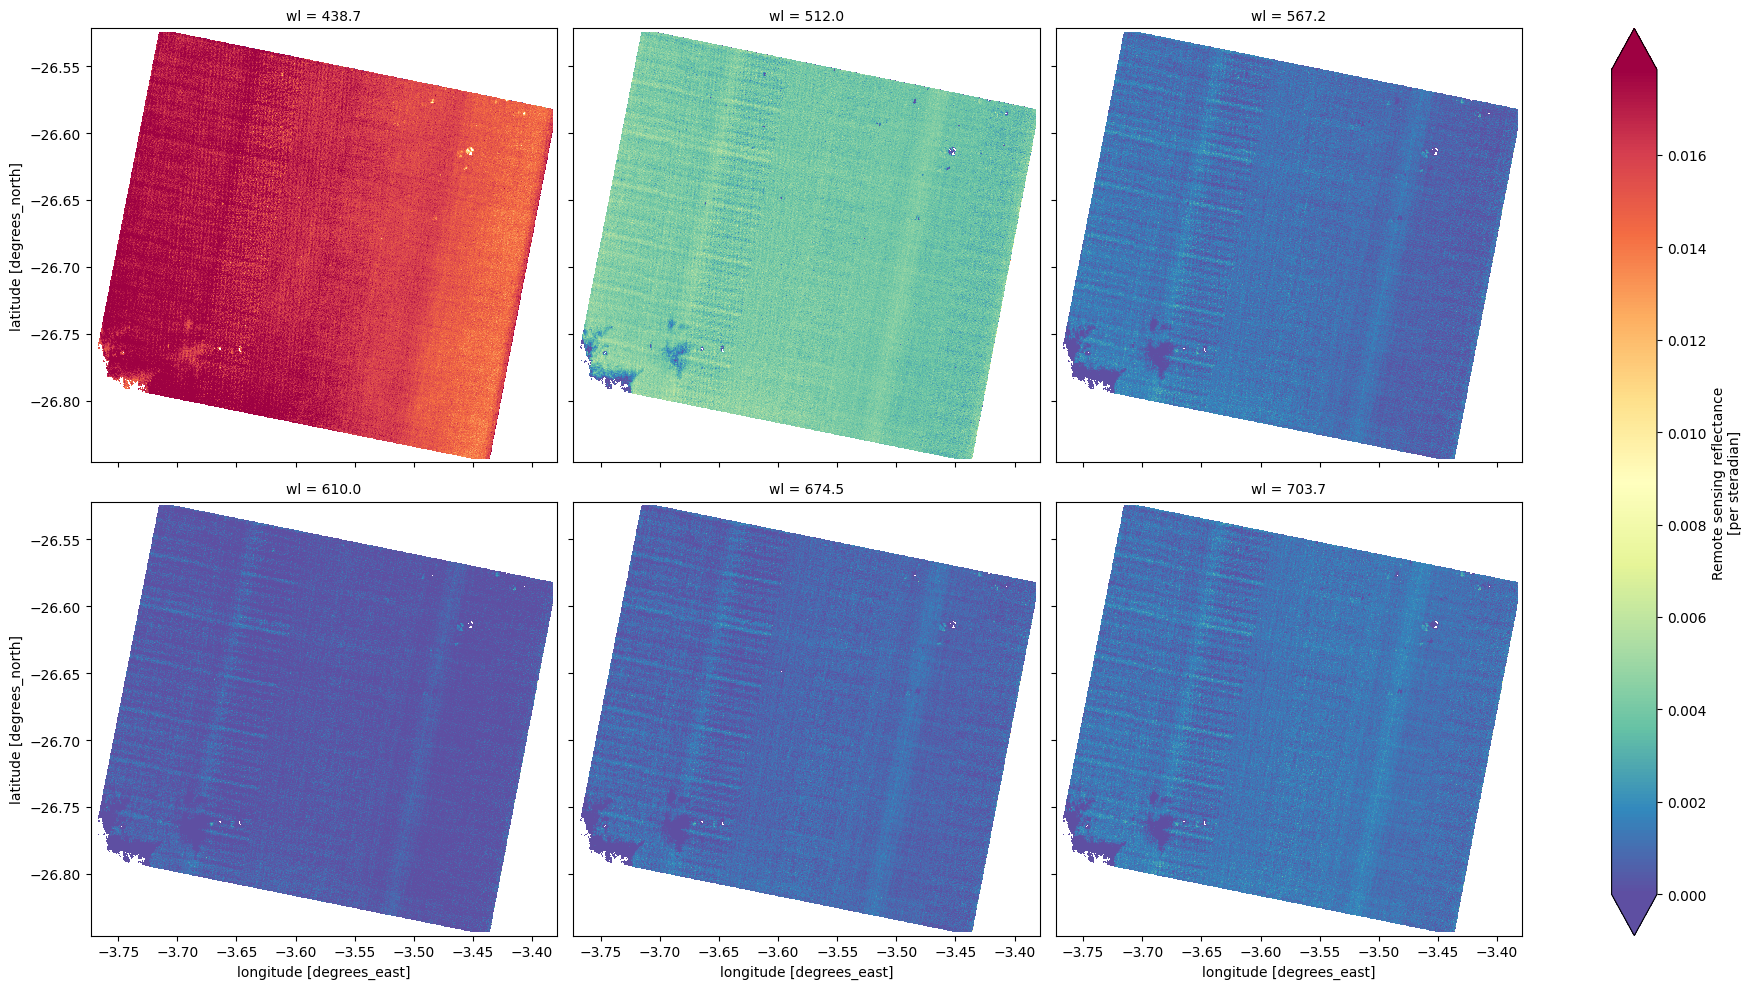

In [4]:
l2a_raster.Rrs.sel(wl=[440,510,565,610,670,705],method="nearest").plot(col='wl',col_wrap=3,size=5,aspect=1.2,robust=True,vmin=0,cmap=plt.cm.Spectral_r)

### Plot other parameters

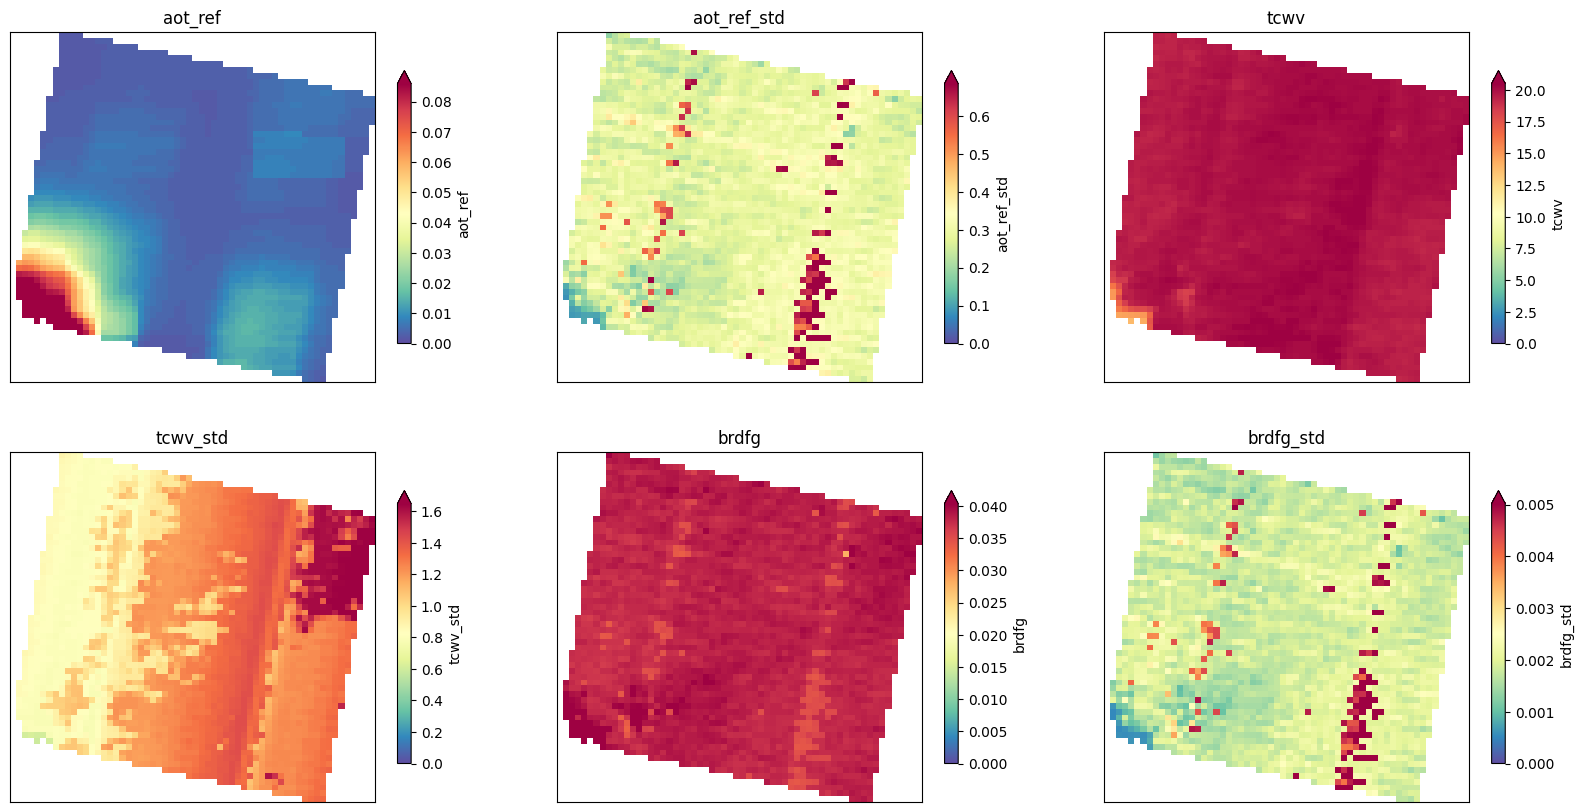

In [5]:
params=['aot_ref','aot_ref_std','tcwv','tcwv_std','brdfg','brdfg_std']

fig,axs = plt.subplots(2,3,figsize=(20,10))
axs=axs.ravel()

for i in range(len(params)):
    l2a_raster[params[i]].plot.imshow(cmap=plt.cm.Spectral_r, robust=True,vmin=0,#vmax=0.201,
                               cbar_kwargs={'shrink': 0.78,'label':params[i]},ax=axs[i]) # extent=extent_val, transform=proj, 
    axs[i].set(xticks=[], yticks=[])
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')    
    axs[i].set_title(params[i])    

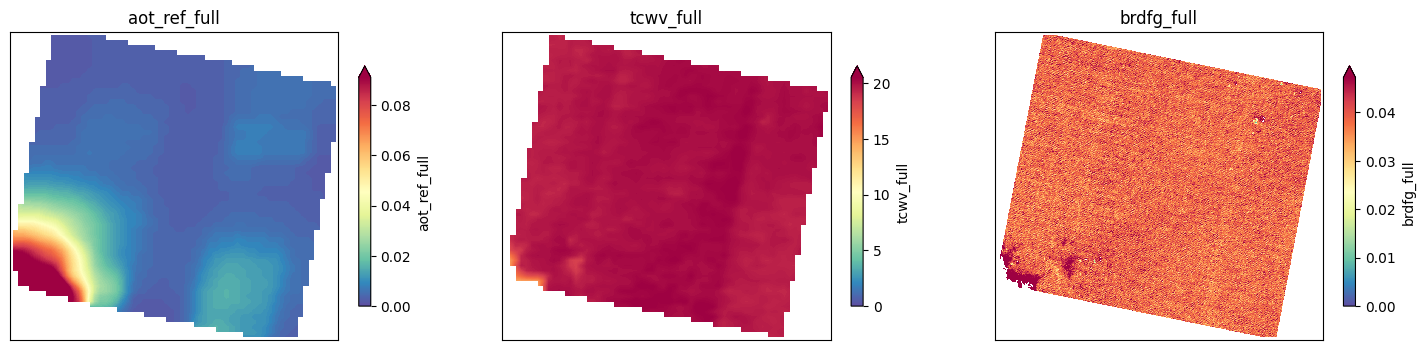

In [6]:
params=['aot_ref_full','tcwv_full','brdfg_full']

fig,axs = plt.subplots(1,3,figsize=(18,4))
axs=axs.ravel()

for i in range(len(params)):
    l2a_raster[params[i]].plot.imshow(cmap=plt.cm.Spectral_r, robust=True,vmin=0,#vmax=0.201,
                               cbar_kwargs={'shrink': 0.78,'label':params[i]},ax=axs[i]) # extent=extent_val, transform=proj, 
    axs[i].set(xticks=[], yticks=[])
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')    
    axs[i].set_title(params[i])    

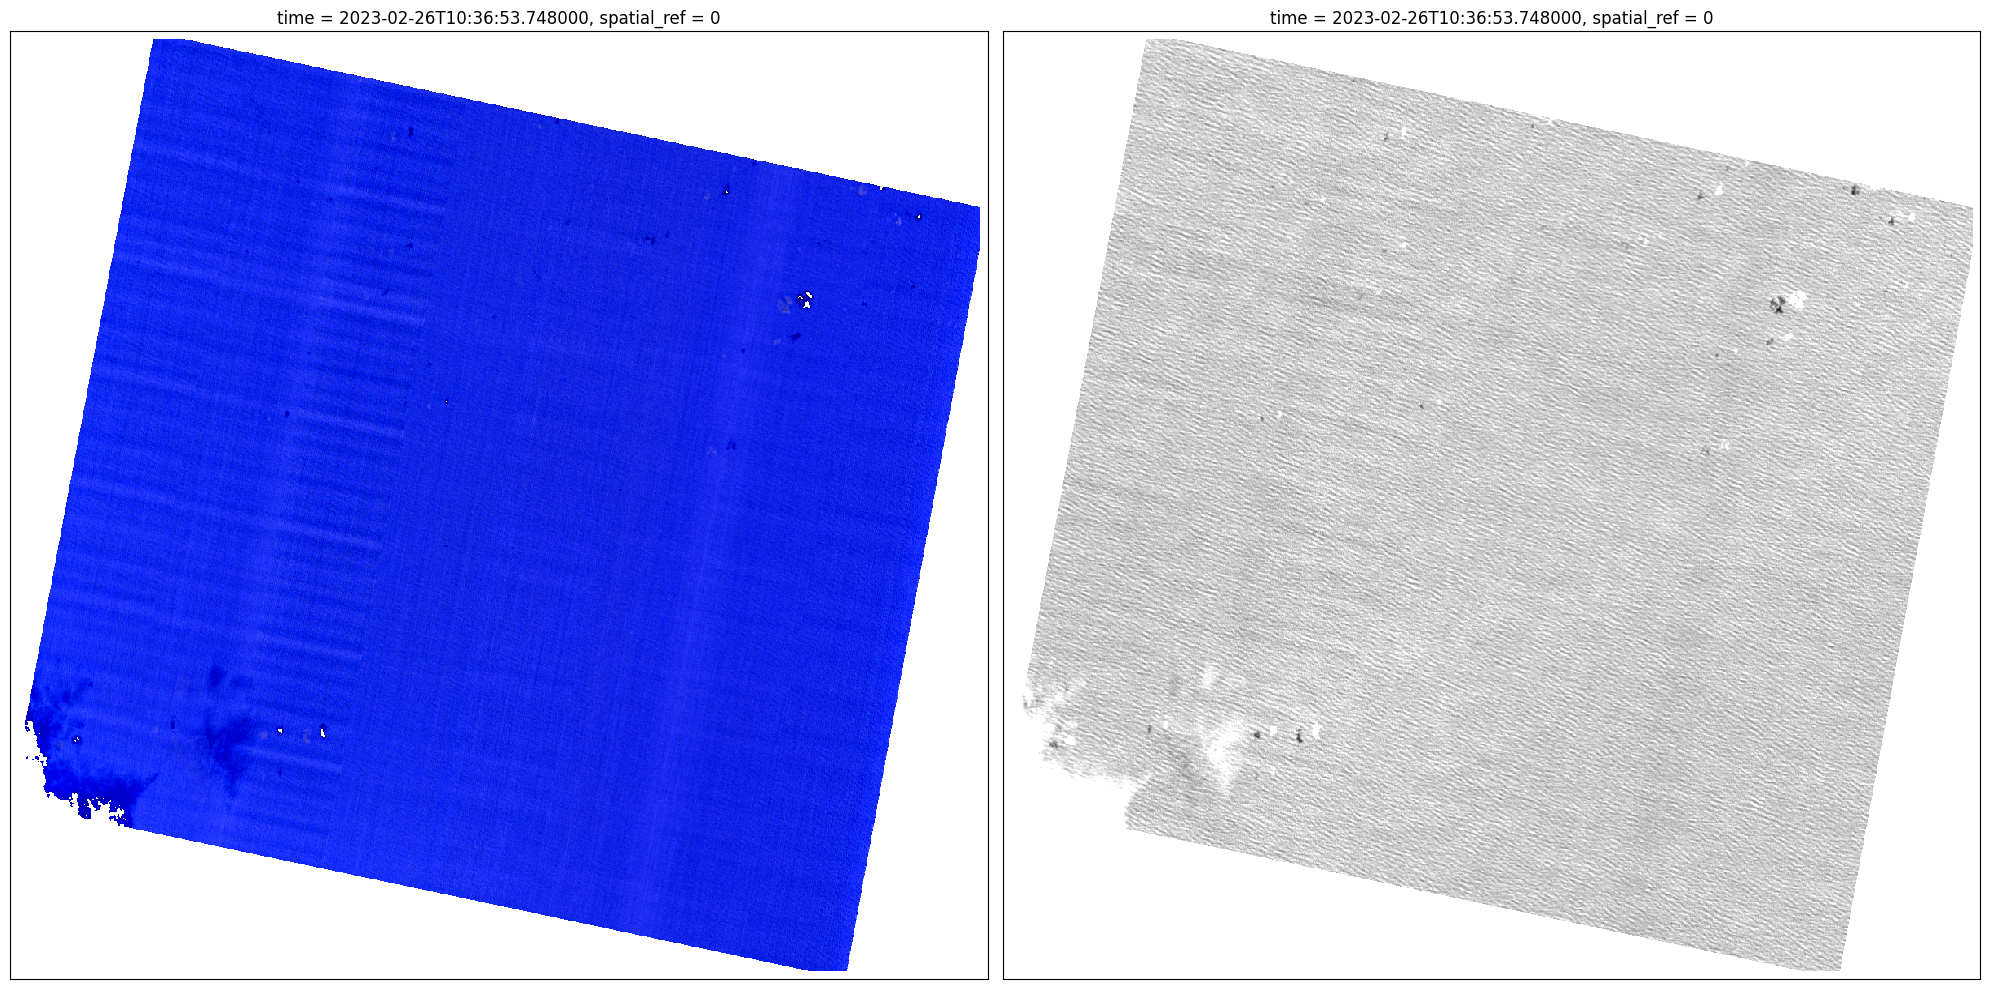

In [7]:
gamma=1#.5

fig,axs = plt.subplots(1,2,figsize=(20,10))
axs=axs.ravel()

rgb=l2a_raster.Rrs.isel(wl=[30,20,6])
adj = xr.DataArray([1.2,1,1],coords={"wl":rgb.wl})
fig = ((rgb*adj)**gamma).plot.imshow(rgb='wl',robust=True,ax=axs[0])#, subplot_kws=dict(projection= l1c.proj))
l2a_raster['brdfg_full'].plot.imshow(cmap=plt.cm.gray, robust=True,vmin=0,ax=axs[1],add_colorbar=False)

for i in range(2):
    axs[i].set(xticks=[], yticks=[])
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')    
plt.tight_layout()        

In [1]:


v=visual.ViewSpectral(l2a_raster.Rrs.isel(wl=range(0,93,5)) ,reproject=True)
print(v)
v.minmax=[0,0.1]
v.minmaxvalues=(0,0.04)
v.visu()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


NameError: name 'visual' is not defined

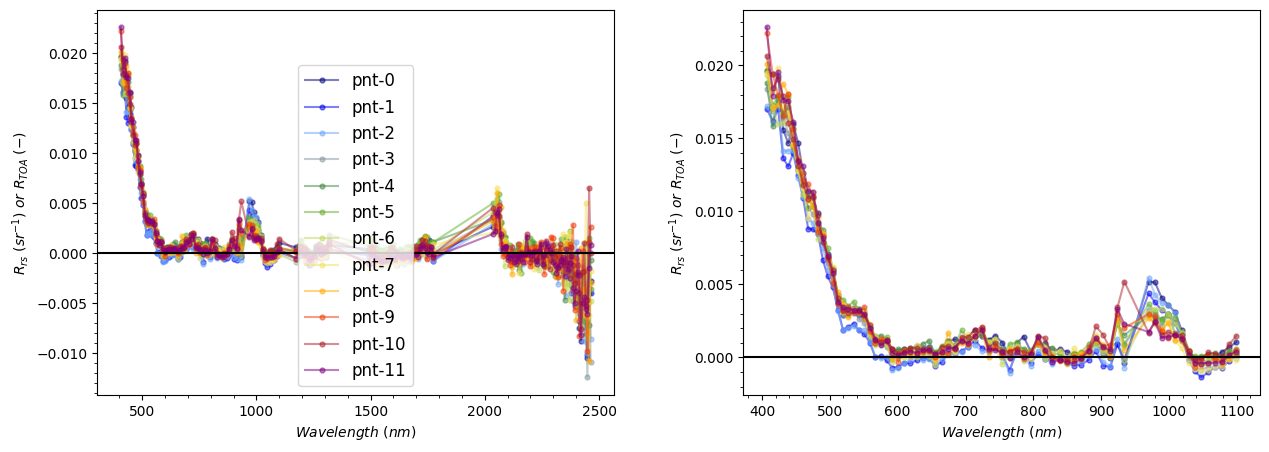

In [11]:
poi_stream = v.poi_stream
geom = poi_stream.data
geom=gpd.points_from_xy(geom['x'],geom['y'])#,crs="EPSG3857")index=[0], c
geom =gpd.GeoDataFrame(crs=3857, geometry=geom).to_crs(l2a_raster.rio.crs)
Ndata = len(geom)
cmap = mpl.colors.LinearSegmentedColormap.from_list("",
                                                    ['navy', "blue", 'lightskyblue',
                                                     "grey",   'forestgreen','yellowgreen',
                                                     "khaki", "gold",
                                                     'orangered', "firebrick", 'purple'])
norm = mpl.colors.Normalize(vmin=0.0,vmax=Ndata-1)


wl_range=slice(400,1100)
alpha=0.5
lw=1.5
ms=3.5

fig,axs = plt.subplots(1,2,figsize=(15,5))#,sharey=True)   
fig.subplots_adjust(hspace=0.05, wspace=0.25)
ax=axs[0]
indexes=np.dstack([geom.geometry.x,geom.geometry.y])[0]
for ii,index in enumerate(indexes):
    color=cmap(norm(ii))
   
    
    boa=l2a_raster.Rrs.sel(x=index[0],y=index[1],method='nearest')
    boa.plot(label='pnt-'+str(ii),marker='o',ms=ms,lw=lw,c=color,alpha=alpha,ax=ax)
    boa.sel(wl=wl_range).plot(label='pnt-'+str(ii),marker='o',ms=ms,lw=lw,alpha=alpha,c=color,ax=axs[1])
#(0.04*prod.Tg_other).plot(marker='o',ms=2.5,lw=0.5,ax=axs[0])
#(0.04*prod.Tg_other).sel(wl=wl_range).plot(marker='o',ms=2.5,lw=0.5,ax=axs[1])
#(0.04*Twv).plot(marker='o',ms=2.5,lw=0.5,ax=axs[0])
#(0.04*Twv).sel(wl=wl_range).plot(marker='o',ms=2.5,lw=0.5,ax=axs[1])

for ax in  axs:
    ax.set_ylabel(r'$R_{rs}\ (sr^{-1})\ or\ R_{TOA}\ (-)$')
    ax.axhline(0,color='k')
    ax.set_xlabel(r'$Wavelength\ (nm)$')
    ax.set_title('')
    ax.minorticks_on() 
    #prod.Twv_raster.mean(['x','y']).plot(marker='o',ms=2.5,lw=0.5)
   

axs[0].legend(fontsize=12)

In [12]:
grstbx.Data.remove_wl_dataarray

<function grstbx.utils.Data.remove_wl_dataarray(xarr, wl_to_remove, drop=True)>

In [13]:
wl_range = slice(400,1050)

df = l2a_raster.Rrs.sel(x=index[0],y=index[1],method='nearest').reset_coords(drop=True).sel(wl=wl_range).to_dataframe().T
df.insert(0, "longitude", index[0])
df.insert(0, "latitude", index[1])
df

wl,latitude,longitude,406.993408,415.838989,423.78476,431.334686,438.656891,446.014709,453.389465,460.73175,...,934.112061,969.84491,979.223999,988.917908,998.908203,1008.644287,1018.535706,1029.343994,1037.987793,1047.675049
Rrs,-26.722687,-3.742086,0.022611,0.017921,0.019544,0.01762,0.017567,0.016137,0.013481,0.013103,...,0.002292,0.001742,0.002402,0.001339,0.001419,0.001543,0.001278,0.000193,-0.000359,-0.000422


In [21]:
wl_range = slice(400,1150)
wl_drop = [(900,1000)]
dfs=[]
for ii,index in enumerate(indexes):
    
    poi = l2a_raster.Rrs.sel(x=index[0],y=index[1],method='nearest').reset_coords(drop=True).sel(wl=wl_range)
    poi = grstbx.Data.remove_wl_dataarray(poi,wl_drop)
    df = poi.to_dataframe().T
    df.insert(0, "longitude", index[0])
    df.insert(0, "latitude", index[1])
    dfs.append(df)
df = pd.concat(dfs).set_index(['latitude','longitude'])
df.columns = df.columns.astype(float)
df

,wl,406.993408,415.838989,423.784760,431.334686,438.656891,446.014709,453.389465,460.731750,468.098450,475.318848,...,1008.644287,1018.535706,1029.343994,1037.987793,1047.675049,1057.573730,1067.794800,1078.216064,1088.760986,1099.277588
latitude,longitude,,,,,,,,,,,,,,,,,,,,,
-26.688754,-3.406470,0.019646,0.019384,0.019271,0.015585,0.014671,0.016005,0.014666,0.012625,0.011013,0.010350,...,0.003128,0.001853,0.000423,-0.000027,-0.000367,-0.000367,0.000075,0.000389,0.000685,0.001047
-26.693479,-3.431953,0.017043,0.016162,0.017010,0.013630,0.013081,0.013967,0.012462,0.010903,0.008807,0.008774,...,0.002372,0.001289,-0.000149,-0.000966,-0.001358,-0.001027,-0.000657,-0.000693,-0.000221,0.000135
-26.700352,-3.474747,0.017203,0.016038,0.017636,0.014130,0.014144,0.014202,0.012294,0.011013,0.009511,0.009205,...,0.003045,0.001577,-0.000025,-0.000762,-0.000850,-0.000676,-0.000690,-0.000425,0.000028,-0.000025
-26.707225,-3.555045,0.018401,0.016866,0.017653,0.016419,0.015389,0.014533,0.012758,0.011184,0.010243,0.009831,...,0.002347,0.001519,-0.000135,-0.000417,-0.000237,-0.000246,-0.000185,-0.000116,0.000287,0.000351
-26.709372,-3.588222,0.018799,0.015822,0.017918,0.016631,0.017134,0.014428,0.012838,0.011852,0.010207,0.010375,...,0.001640,0.001140,0.000290,-0.000036,0.000036,0.000216,0.000320,0.000116,0.000392,0.000199
-26.710231,-3.620437,0.019715,0.017280,0.017843,0.016800,0.017854,0.015706,0.013404,0.011836,0.011295,0.010908,...,0.002728,0.001739,0.000287,0.000086,0.000097,0.000182,-0.000011,-0.000050,0.000409,0.000574
-26.712809,-3.640632,0.019318,0.017175,0.015958,0.016049,0.016662,0.014580,0.012838,0.011112,0.010784,0.010381,...,0.002311,0.001693,0.000508,-0.000489,-0.000389,-0.000138,-0.000240,-0.000055,0.000091,0.000472
-26.714097,-3.668520,0.019472,0.018274,0.019817,0.017128,0.016728,0.014621,0.012769,0.011593,0.009580,0.011322,...,0.001151,0.000643,-0.000411,-0.000787,-0.000927,-0.000864,-0.000679,-0.000646,-0.000121,-0.000177
-26.715815,-3.692080,0.020127,0.017065,0.017264,0.018741,0.018012,0.014503,0.013608,0.012656,0.010754,0.010342,...,0.001179,0.001104,0.000105,-0.000384,-0.000593,-0.000436,0.000017,-0.000450,-0.000116,0.000334


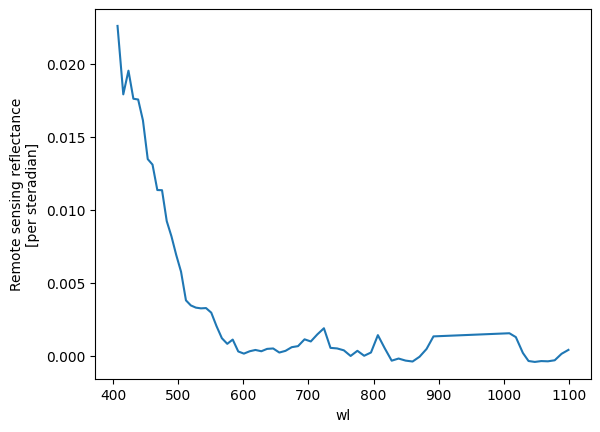

In [17]:
poi.plot()

<Axes: xlabel='wl'>

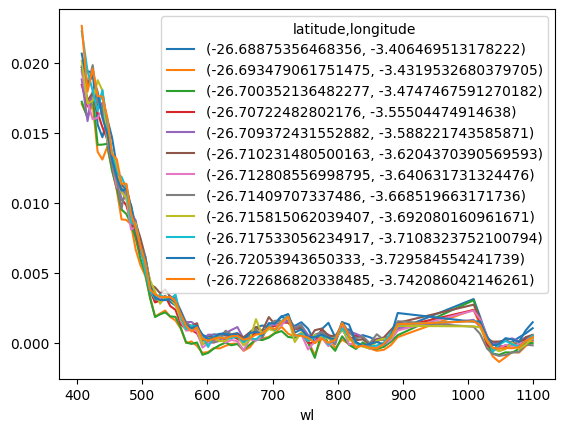

In [22]:
df.T.plot() #to_csv()

### Extract from csv file of Lon/Lat

In [26]:
pins = pd.read_excel('Pins_Data.xlsx')
pins

,Name,Longitude,Latitude,Label
0,2/26/2023T4:22:00 AM,-3.377133,-26.699997,P263
1,2/26/2023T4:23:00 AM,-3.378891,-26.700007,P264
2,2/26/2023T4:24:00 AM,-3.380640,-26.699992,P265
3,2/26/2023T4:25:00 AM,-3.382356,-26.699999,P266
4,2/26/2023T4:26:00 AM,-3.384077,-26.700018,P267
...,...,...,...,...
769,2/26/2023T5:11:00 PM,-3.768666,-26.699997,P1032
770,2/26/2023T5:12:00 PM,-3.770182,-26.700015,P1033
771,2/26/2023T5:13:00 PM,-3.771706,-26.700008,P1034
772,2/26/2023T5:14:00 PM,-3.773252,-26.700007,P1035


In [33]:
for ii,pin in pins.iterrows():
    pin
pin.Longitude

-3.77480100000004

In [36]:
wl_range = slice(400,1150)
wl_drop = [(900,1000)]
longitude='Longitude'
latitude ='Latitude'
params = ['Label',longitude,latitude]
dfs=[]
for ii,pin in pins.iterrows():
    lon,lat = pin[longitude],pin[latitude]
    
    poi = l2a_raster.Rrs.sel(x=lon,y=lat,method='nearest').reset_coords(drop=True).sel(wl=wl_range)
    poi = grstbx.Data.remove_wl_dataarray(poi,wl_drop)
    df = poi.to_dataframe().T
    for param in params:
        df.insert(0, param, pin[param])
       
    dfs.append(df)
df = pd.concat(dfs).set_index(params)
df.columns = df.columns.astype(float)
df

,,wl,406.993408,415.838989,423.784760,431.334686,438.656891,446.014709,453.389465,460.731750,468.098450,475.318848,...,1008.644287,1018.535706,1029.343994,1037.987793,1047.675049,1057.573730,1067.794800,1078.216064,1088.760986,1099.277588
Label,Longitude,Latitude,,,,,,,,,,,,,,,,,,,,,
P263,-3.377133,-26.699997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P264,-3.378891,-26.700007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P265,-3.380640,-26.699992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P266,-3.382356,-26.699999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P267,-3.384077,-26.700018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P1032,-3.768666,-26.699997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P1033,-3.770182,-26.700015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P1034,-3.771706,-26.700008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 0, '$Wavelength\\ (nm)$')

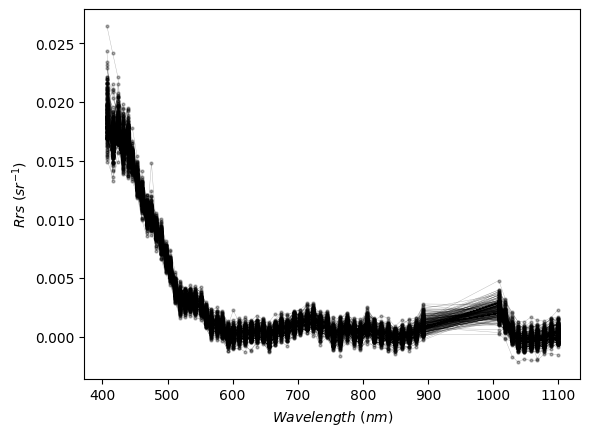

In [47]:
df.T.plot(marker='o',ms=2,lw=0.3,color='k',alpha=0.3,legend=False)
plt.ylabel(r'$Rrs\ (sr^{-1})$')
plt.xlabel(r'$Wavelength\ (nm)$')


### Save extracted pixels into csv file

In [40]:
df.to_csv('garaba_poi.csv')